# Simulated verificaition of dynamics on SWING PHASE

In [3]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import scipy.io as sio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import ipywidgets as widgets
from IPython.display import display
import rootpath

In [3]:
# Loading the data
root_dir = rootpath.detect()
data = np.load(f'{root_dir}/data/Exp-A2B 10000-20241226_230233/StepResponse_list.npy')
# data = np.load('../data/Exp-A2B 10000-20241223_131316/StaticState_list.npy')

ExpStructList_mat = sio.loadmat(f'{root_dir}/AtoBMatlab/ExpData.mat')

In [ ]:
# Loading the data (json) 5m+
import pandas as pd
df = pd.read_json('data/swing_experiment_data.json')
print(df.head())

   theta_1_start  theta_2_start  theta_1_end  theta_2_end         F1  \
0       0.680678        0.15708     0.680678     0.157080 -20.973844   
1       0.680678        0.15708     0.680678     0.314159 -20.973844   
2       0.680678        0.15708     0.680678     0.471239 -20.973844   
3       0.680678        0.15708     0.680678     0.628319 -20.973844   
4       0.680678        0.15708     0.680678     0.785398 -20.973844   

          F2   F1_prime   F2_prime  \
0  50.239806 -20.973844  50.239806   
1  50.239806 -21.163237  46.142816   
2  50.239806 -21.132873  41.755686   
3  50.239806 -20.963836  37.080380   
4  50.239806 -20.713508  32.150234   

                                            time_sim  \
0  [0.0, 0.001, 0.002, 0.003, 0.004, 0.005, 0.006...   
1  [0.0, 0.001, 0.002, 0.003, 0.004, 0.005, 0.006...   
2  [0.0, 0.001, 0.002, 0.003, 0.004, 0.005, 0.006...   
3  [0.0, 0.001, 0.002, 0.003, 0.004, 0.005, 0.006...   
4  [0.0, 0.001, 0.002, 0.003, 0.004, 0.005, 0.006...   

 

In [4]:
# read the csv
df = pd.read_csv('data/swing_exp_data.csv')

In [ ]:
df.iloc[0]["time_sim"]

'[0.0000e+00 1.0000e-03 2.0000e-03 ... 1.4997e+01 1.4998e+01 1.4999e+01]'

In [10]:
np.fromstring((df.iloc[0]["time_sim"]).strip('[]'), sep=' ')


/var/folders/j1/jvx4zg8j2kd3f52pd5cjwjrw0000gn/T/ipykernel_66992/252834127.py:1: DeprecationWarning: string or file could not be read to its end due to unmatched data; this will raise a ValueError in the future.
  np.fromstring((df.iloc[0]["time_sim"]).strip('[]'), sep=' ')


array([0.   , 0.001, 0.002])

In [11]:
# read the npy
import numpy as np
t_sim_list = np.load('data/swing_exp_data_t.npy', allow_pickle=True)
theta1_sim_list = np.load('data/swing_exp_data_theta1.npy', allow_pickle=True)
theta2_sim_list = np.load('data/swing_exp_data_theta2.npy', allow_pickle=True)


In [ ]:
# Data from theo sim (Matlab)
from scipy.io import loadmat
data = loadmat('data/matlab_theo/swing_expdata.mat', simplify_cells=True)

t_all = data['t_all']
Xt_all = data['Xt_all']

(585, 4)

In [4]:
# 解包Matlab

StartPoint_index = 31    # 按照实验序号
EndPoint_index = 62      # 按照实验序号

def get_matlab_data(StartPoint_index, EndPoint_index):
    group = StartPoint_index*100 + EndPoint_index
    t_matlab = ExpStructList_mat['ExpData'][0][group][0][:].flatten()
    Xt_matlab = ExpStructList_mat['ExpData'][0][group][1][:]
    theta1_matlab = ExpStructList_mat['ExpData'][0][group][1][:, 0]
    theta2_matlab = ExpStructList_mat['ExpData'][0][group][1][:, 1]
    return t_matlab, theta1_matlab, theta2_matlab

In [5]:
print(ExpStructList_mat['ExpData'][0][9999][0].shape)

(481, 1)


In [6]:
# 解包-Mujoco大数据包
Theta1_array = np.linspace(math.pi/6, math.pi*2/3, 10)
Theta2_array = np.linspace(0, math.pi/2, 10)

data_matrix = data.reshape(100, 100, data.shape[1], data.shape[2])  # 每一行是相同的theta1，每一列是相同的theta2

# 解析坐标
# copy from Run
StartPointArray = []
for theta_1 in Theta1_array:
  for theta_2 in Theta2_array:
    StartPointArray.append([theta_1, theta_2])
StartPointArray = np.array(StartPointArray)
EndPointArray = StartPointArray

# StartPoint_index = 0    # 按照实验序号
# EndPoint_index = 2      # 按照实验序号
# t_bias = (100*StartPoint_index + EndPoint_index) * 20   # 不太准确

def get_mujoco_data(StartPoint_index, EndPoint_index):
  Pos_startPoint = StartPointArray[StartPoint_index]
  Pos_endPoint = EndPointArray[EndPoint_index]

  exp1data = np.array(data_matrix[StartPoint_index][EndPoint_index])

  t_mujoco = exp1data[:, 0] - exp1data[0, 0]  # 归一化时间
  theta1_mujoco = exp1data[:, 1]+math.pi/2
  theta2_mujoco = exp1data[:, 2]
  return t_mujoco, theta1_mujoco, theta2_mujoco



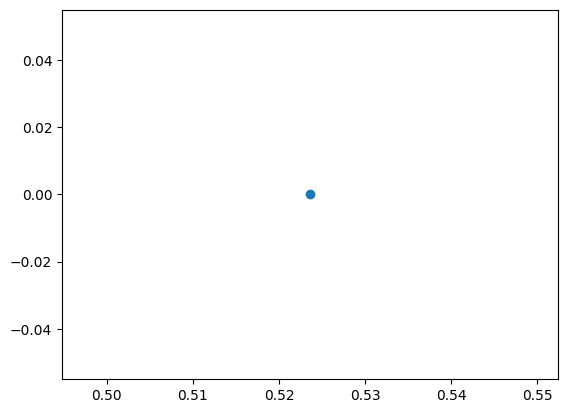

In [7]:
StartPointArray[0]
plt.scatter(*StartPointArray[0])

In [8]:


# 创建滑动条
si_slider = widgets.IntSlider(value=22, min=0, max=99, step=1, description='StartPoint_index')
ei_slider = widgets.IntSlider(value=55, min=0, max=99, step=1, description='EndPoint_index')

from matplotlib import rcParams

config = {
    "font.family":'Times New Roman',  # 设置字体类型
    "axes.unicode_minus": False, #解决负号无法显示的问题
    "font.size": 16,  # 设置字体大小
}
rcParams.update(config)

legendSet = {
    'loc': 'upper right',
    'fontsize': 12,
}


# 绘图函数
def update_plot(si, ei):
    # Force
    print(f"StartPoint: {StartPointArray[si]}, EndPoint: {EndPointArray[ei]}")

    # 获取数据
    t_mujoco, theta1_mujoco, theta2_mujoco = get_mujoco_data(si, ei)
    t_matlab, theta1_matlab, theta2_matlab = get_matlab_data(si, ei)
    

    # 0-10做插值
    t_interp = np.linspace(0, 10, 1000)
    theta1_mujoco = np.interp(t_interp, t_mujoco, theta1_mujoco)
    theta2_mujoco = np.interp(t_interp, t_mujoco, theta2_mujoco)
    theta1_matlab = np.interp(t_interp, t_matlab, theta1_matlab)
    theta2_matlab = np.interp(t_interp, t_matlab, theta2_matlab)    
    
    fig, axs = plt.subplots(2, 2, figsize=(12, 12), dpi=200)  # 两行两列的图布局
    
    # --- 左上：时间曲线 ---
    # axs[0, 0].plot(t_interp, theta1_mujoco, label='Mujoco theta1')
    axs[0, 0].plot(t_interp, theta2_mujoco, label='Equi-Mujoco')
    # axs[0, 0].plot(t_interp, theta1_matlab, label='Matlab theta1')
    axs[0, 0].plot(t_interp, theta2_matlab, label='Theo-Matlab')
    axs[0, 0].set_xlabel('Time/s')
    axs[0, 0].set_ylabel('Theta2/rad')
    axs[0, 0].set_title('Theta2 vs Time')

    # 绘制角度限制横线
    # axs[0, 0].axhline(y=math.pi*2/3, color='r', linestyle='--', label='Theta1 Limit')
    # axs[0, 0].axhline(y=math.pi/6, color='r', linestyle='--', label='Theta2 Limit')
    # axs[0, 0].axhline(y=math.pi/2, color='b', linestyle='--', label='Theta2 Zero')
    # axs[0, 0].axhline(y=0, color='b', linestyle='--', label='Theta1 Start')

    # 标注起始点
    axs[0, 0].scatter(t_interp[0], theta2_mujoco[0], s=100, color='purple', label='Start Point', marker='*', alpha=0.9, zorder=5)
    axs[0, 0].scatter(t_interp[-1], theta2_mujoco[-1], s=100, color='red', label='End Point', marker='*', alpha=0.9, zorder=5)
    axs[0, 0].legend(**legendSet)

    edge = math.pi/3*0
    axs[0, 0].set_ylim([0, math.pi/2])
    
    # --- 右上：轨迹图 ---
    axs[0, 1].plot(theta1_mujoco, theta2_mujoco, label='Equivalent Sim', alpha=0.6)  # 连线
    axs[0, 1].scatter(theta1_mujoco, theta2_mujoco, s=3, label='Equivalent-Point')  # 散点

    axs[0, 1].plot(theta1_matlab, theta2_matlab, label='Theoretical Sim', alpha=0.6)  # 连线
    axs[0, 1].scatter(theta1_matlab, theta2_matlab, s=3, label='Theoretical-Point')  # 散点


    # 绘制角度方格——一个方形        
    # rect = plt.Rectangle((math.pi/6, 0), math.pi*2/3-math.pi/6, math.pi/2, linewidth=1, edgecolor='r', facecolor='none')
    # axs[0, 1].add_patch(rect)
    
    axs[0, 1].set_xlabel('Theta1/rad')
    axs[0, 1].set_ylabel('Theta2/rad')
    axs[0, 1].set_title('Theta Trajectory')
    axs[0, 1].set_xlim([math.pi/6-edge, math.pi*2/3+edge])
    axs[0, 1].set_ylim([0-edge, math.pi/2+edge])

    # draw all the grid point-StartPointArray
    for i in range(len(StartPointArray)):
        axs[0, 1].scatter(StartPointArray[i][0], StartPointArray[i][1], s=3, color='green', alpha=0.5)
        # axs[0, 1].text(StartPointArray[i][0], StartPointArray[i][1], str(i), fontsize=8, color='green')

    # end point 
    axs[0, 1].scatter(theta1_mujoco[0], theta2_mujoco[0], s=100, color='purple', label='Start Point', marker='*', alpha=0.9, zorder=5)
    axs[0, 1].scatter(theta1_mujoco[-1], theta2_mujoco[-1], s=100, color='red', label='End Point', marker='*', alpha=0.9, zorder=5)
    axs[0, 1].grid(True, linestyle='--', alpha=0.5)
    
    axs[0, 1].legend(**legendSet)

    
    # --- 左下：a_1cos(theta1) + a_2cos(theta2) ---
    a1 = 0.25  # 你可以根据需要调整
    a2 = 0.25  # 你可以根据需要调整
    flip = -1  # You can adjust this value as needed

    x_mujoco = (a1 * np.cos(theta1_mujoco) + a2 * np.cos(theta2_mujoco + theta1_mujoco)) * flip
    y_mujoco = (a1 * np.sin(theta1_mujoco) + a2 * np.sin(theta2_mujoco + theta1_mujoco)) * flip
    x_matlab = (a1 * np.cos(theta1_matlab) + a2 * np.cos(theta2_matlab + theta1_matlab)) * flip
    y_matlab = (a1 * np.sin(theta1_matlab) + a2 * np.sin(theta2_matlab + theta1_matlab)) * flip

    knee_x_mujoco = (a1 * np.cos(theta1_mujoco))*flip
    knee_y_mujoco = (a1 * np.sin(theta1_mujoco))*flip
    knee_x_matlab = (a1 * np.cos(theta1_matlab))*flip
    knee_y_matlab = (a1 * np.sin(theta1_matlab))*flip

    zero_ = np.zeros_like(knee_x_mujoco)

    axs[1, 0].plot(x_mujoco, y_mujoco, label='Equivalent Trajectory')
    axs[1, 0].plot(x_matlab, y_matlab, label='Theoretical Trajectory')

    # interesting point
    index_interesting = [0, -1, len(t_interp)//30, len(t_interp)//100]
    
    for index in index_interesting:
        axs[1, 0].plot([zero_[index], knee_x_mujoco[index], x_mujoco[index]], [zero_[index], knee_y_mujoco[index], y_mujoco[index]], '-' if index < 2 else '--', color='purple', markersize=10, alpha=1 if index < 2 else 0.8)

    # 标注起始点
    axs[1, 0].scatter(x_mujoco[0], y_mujoco[0], s=100, color='purple', label='Start Point', marker='*', alpha=0.9, zorder=5)
    axs[1, 0].scatter(x_mujoco[-1], y_mujoco[-1], s=100, color='red', label='End Point', marker='*', alpha=0.9, zorder=5)

    axs[1, 0].set_xlabel('x/m')
    axs[1, 0].set_ylabel('y/m')

    axs[1, 0].set_xlim([-0.3, 0.3])
    axs[1, 0].set_ylim(np.array([0.5, -0.1])*flip)
    axs[1, 0].set_title('Foot Trajectory')
    axs[1, 0].grid(True, linestyle='--', alpha=0.5)
    axs[1, 0].legend(**legendSet)


    # --- 右下：theta2随时间变化 ---
    axs[1, 1].plot(theta1_mujoco, t_interp, label='Equivalent Theta1')
    axs[1, 1].plot(theta1_matlab, t_interp, label='Theoretical Theta1')
    
    axs[1, 1].set_xlabel('Theta1/rad')
    axs[1, 1].set_ylabel('Time/s')

    # 标注起始点
    axs[1, 1].scatter(theta1_mujoco[0], t_interp[0], s=100, color='purple', label='Start Point', marker='*', alpha=0.9, zorder=5)
    axs[1, 1].scatter(theta1_mujoco[-1], t_interp[-1], s=100, color='red', label='End Point', marker='*', alpha=0.9, zorder=5)

    axs[1, 1].legend(**legendSet)
    axs[1, 1].set_title('Theta1 vs Time')
    axs[1, 1].set_xlim([math.pi/6, math.pi*2/3])

    plt.tight_layout()
    plt.show()

# 显示交互绘图
interactive_plot = widgets.interactive(update_plot, si=si_slider, ei=ei_slider)
display(interactive_plot)

interactive(children=(IntSlider(value=22, description='StartPoint_index', max=99), IntSlider(value=55, descrip…

In [9]:
import ipywidgets as widgets
from IPython.display import display

# 创建滑动条
si_slider = widgets.IntSlider(value=31, min=0, max=99, step=1, description='StartPoint_index')
ei_slider = widgets.IntSlider(value=62, min=0, max=99, step=1, description='EndPoint_index')

# 绘图函数
def update_plot(si, ei):
    # if ei < si:
    #     ei = si
    
    # 获取数据
    t_mujoco, theta1_mujoco, theta2_mujoco = get_mujoco_data(si, ei)
    t_matlab, theta1_matlab, theta2_matlab = get_matlab_data(si, ei)

    # 0-10做插值
    t_interp = np.linspace(0, 10, 1000)
    theta1_mujoco = np.interp(t_interp, t_mujoco, theta1_mujoco)
    theta2_mujoco = np.interp(t_interp, t_mujoco, theta2_mujoco)
    theta1_matlab = np.interp(t_interp, t_matlab, theta1_matlab)
    theta2_matlab = np.interp(t_interp, t_matlab, theta2_matlab)    
    
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # 两个图：时间曲线 + 轨迹图
    
    # --- 左侧：时间曲线 ---
    axs[0].plot(t_interp, theta1_mujoco, label='Mujoco theta1')
    axs[0].plot(t_interp, theta2_mujoco, label='Mujoco theta2')
    axs[0].plot(t_interp, theta1_matlab, label='Matlab theta1')
    axs[0].plot(t_interp, theta2_matlab, label='Matlab theta2')
    
    axs[0].set_xlabel('Time')
    axs[0].set_ylabel('Theta Values')
    axs[0].legend()
    axs[0].set_title('Theta over Time')

    # 绘制角度限制横线
    axs[0].axhline(y=math.pi*2/3, color='r', linestyle='--', label='Theta1 Limit')
    axs[0].axhline(y=math.pi/6, color='r', linestyle='--', label='Theta2 Limit')
    axs[0].axhline(y=math.pi/2, color='b', linestyle='--', label='Theta2 Zero')
    axs[0].axhline(y=0, color='b', linestyle='--', label='Theta1 Start')

    edge = math.pi/3*0
    axs[0].set_ylim([0-edge, math.pi*2/3+edge])
    
    # --- 右侧：轨迹图 ---
    # axs[1].scatter(theta1_mujoco, theta2_mujoco, label='Mujoco Trajectory', c=t_interp, cmap='viridis', s=5)
    # axs[1].scatter(theta1_matlab, theta2_matlab, label='Matlab Trajectory', c=t_interp, cmap='plasma', s=5)
    # Mujoco Trajectory：连线+散点
    axs[1].plot(theta1_mujoco, theta2_mujoco, color='blue', label='Mujoco Trajectory')  # 连线
    sc1 = axs[1].scatter(theta1_mujoco, theta2_mujoco, s=3, label='Mujoco Points')  # 散点

    # Matlab Trajectory：连线+散点
    axs[1].plot(theta1_matlab, theta2_matlab, color='orange', label='Matlab Trajectory')  # 连线
    sc2 = axs[1].scatter(theta1_matlab, theta2_matlab, s=3, label='Matlab Points')  # 散点

    # 添加颜色条，增强可读性
    # cbar1 = plt.colorbar(sc1, ax=axs[1])
    # cbar1.set_label('Time (Mujoco)', rotation=270, labelpad=15)

    # cbar2 = plt.colorbar(sc2, ax=axs[1])
    # cbar2.set_label('Time (Matlab)', rotation=270, labelpad=15)
    
    axs[1].set_xlabel('Theta1')
    axs[1].set_ylabel('Theta2')
    axs[1].legend()
    axs[1].set_title('Theta1 vs Theta2 Trajectory')

    # 绘制角度方格——一个方形        
    rect = plt.Rectangle((math.pi/6, 0), math.pi*2/3-math.pi/6, math.pi/2, linewidth=1, edgecolor='r', facecolor='none')
    axs[1].add_patch(rect)
    
    axs[1].set_xlim([math.pi/6-edge, math.pi*2/3+edge])
    axs[1].set_ylim([0-edge, math.pi/2+edge])

    # 绘制格点


    plt.tight_layout()
    plt.show()

# 显示交互绘图
interactive_plot = widgets.interactive(update_plot, si=si_slider, ei=ei_slider)
display(interactive_plot)

interactive(children=(IntSlider(value=31, description='StartPoint_index', max=99), IntSlider(value=62, descrip…

(9999, 9)


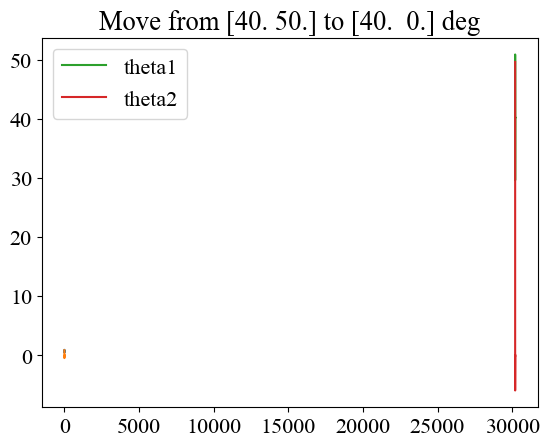

array([30200.0930057, 30200.0940057, 30200.0950057, ..., 30210.0890057,
       30210.0900057, 30210.0910057])

In [10]:
# Paper: 展示其中一组数据

StartPoint_index = 15    # 按照实验序号
EndPoint_index = 10      # 按照实验序号

group = StartPoint_index*100 + EndPoint_index
t_matlab = ExpStructList_mat['ExpData'][0][group][0][:].flatten()
Xt_matlab = ExpStructList_mat['ExpData'][0][group][1][:]
theta1_matlab = ExpStructList_mat['ExpData'][0][group][1][:, 0]
theta2_matlab = ExpStructList_mat['ExpData'][0][group][1][:, 1]
plt.plot(t_matlab, theta1_matlab)
plt.plot(t_matlab, theta2_matlab)


# 解包-Mujoco大数据包
Theta1_array = np.linspace(math.pi/6, math.pi*2/3, 10)
Theta2_array = np.linspace(0, math.pi/2, 10)

data_matrix = data.reshape(100, 100, data.shape[1], data.shape[2])  # 每一行是相同的theta1，每一列是相同的theta2

# 解析坐标
# copy from Run
StartPointArray = []
for theta_1 in Theta1_array:
  for theta_2 in Theta2_array:
    StartPointArray.append([theta_1, theta_2])
StartPointArray = np.array(StartPointArray)
EndPointArray = StartPointArray

# StartPoint_index = 0    # 按照实验序号
# EndPoint_index = 2      # 按照实验序号
# t_bias = (100*StartPoint_index + EndPoint_index) * 20   # 不太准确

Pos_startPoint = StartPointArray[StartPoint_index]
Pos_endPoint = EndPointArray[EndPoint_index]

exp1data = np.array(data_matrix[StartPoint_index][EndPoint_index])
print(exp1data.shape)
plt.plot(exp1data[:, 0], (exp1data[:, 1]+math.pi/2)/math.pi*180, label='theta1')
plt.plot(exp1data[:, 0], exp1data[:, 2]/math.pi*180, label="theta2")
plt.title(f"Move from {Pos_startPoint/math.pi*180} to {Pos_endPoint/math.pi*180} deg")
plt.legend()
plt.show()

exp1data[:, 0]


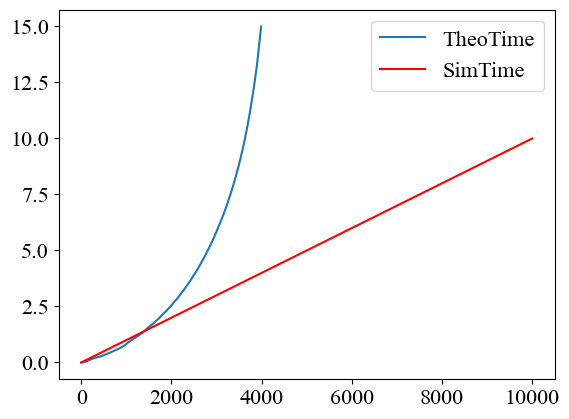

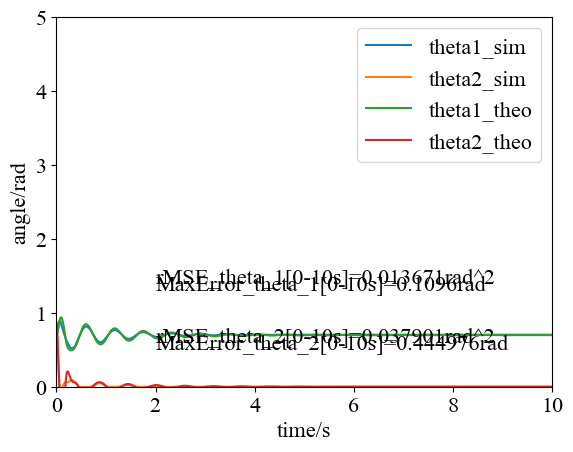

(np.float64(0.013671279804266178),
 np.float64(0.03790111903610909),
 np.float64(0.008762776704053695),
 np.float64(0.009209639805262949),
 np.float64(0.10959979848976908),
 np.float64(0.44497614930762697))

In [11]:
# 对比

def step_response_compare(t_array_matlab, theta1_array_matlab, theta2_array_matlab, t_array_mujoco, theta1_array_mujoco, theta2_array_mujoco, if_plot=True):
    # 时间并没有对齐
    if if_plot:
        plt.plot(t_array_matlab, label="TheoTime")
        plt.plot(t_array_mujoco, 'r', label="SimTime")
        plt.legend()
        plt.show()

        plt.plot(t_array_mujoco, theta1_array_mujoco, label="theta1_sim")
        plt.plot(t_array_mujoco, theta2_array_mujoco, label="theta2_sim")
        plt.plot(t_array_matlab, theta1_array_matlab, label="theta1_theo")
        plt.plot(t_array_matlab, theta2_array_matlab, label="theta2_theo")
        plt.legend()
        plt.xlabel("time/s")
        plt.ylabel("angle/rad")
        plt.xlim([0, 10])
        plt.ylim([0, 5])


    # cal the MSE: 需要使用插值计算： 考虑[0-4s]区间
    t_intervel = np.linspace(0, 10, 1000)
    theta1_sim_intervel = np.interp(t_intervel, t_array_mujoco, theta1_array_mujoco)
    theta2_sim_intervel = np.interp(t_intervel, t_array_mujoco, theta2_array_mujoco)
    theta1_theo_intervel = np.interp(t_intervel, t_array_matlab, theta1_array_matlab)
    theta2_theo_intervel = np.interp(t_intervel, t_array_matlab, theta2_array_matlab)

    rmse_theta1 = np.sqrt(np.mean(np.square(theta1_sim_intervel-theta1_theo_intervel)))
    rmse_theta2 = np.sqrt(np.mean(np.square(theta2_sim_intervel-theta2_theo_intervel)))
    mae_theta1 = np.mean(np.abs(theta1_sim_intervel-theta1_theo_intervel))
    mae_theta2 = np.mean(np.abs(theta2_sim_intervel-theta2_theo_intervel))
    maxerror_theta1 = np.max(np.abs(theta1_sim_intervel-theta1_theo_intervel))
    maxerror_theta2 = np.max(np.abs(theta2_sim_intervel-theta2_theo_intervel))

    if if_plot:
        plt.text(2, 1.4, f"rMSE_theta_1[0-10s]={round(rmse_theta1, 6)}rad^2")
        plt.text(2, 1.3, f"MaxError_theta_1[0-10s]={round(maxerror_theta1, 6)}rad")
        plt.text(2, 0.6, f"rMSE_theta_2[0-10s]={round(rmse_theta2, 6)}rad^2")
        plt.text(2, 0.5, f"MaxError_theta_2[0-10s]={round(maxerror_theta2, 6)}rad")

        plt.show()
    
    return rmse_theta1, rmse_theta2, mae_theta1, mae_theta2, maxerror_theta1, maxerror_theta2
t_bias = exp1data[0, 0]
step_response_compare(t_matlab.flatten(), theta1_matlab, theta2_matlab, exp1data[:, 0]-t_bias, (exp1data[:, 1]+math.pi/2), exp1data[:, 2])

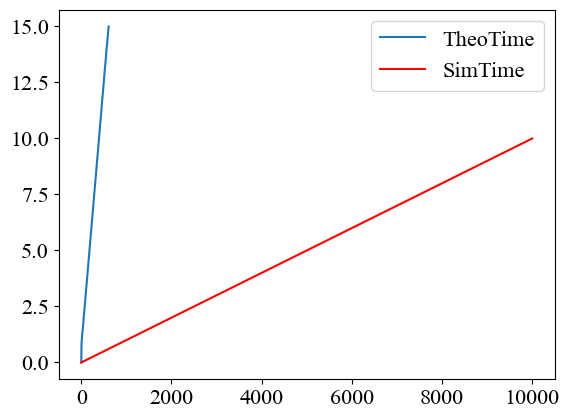

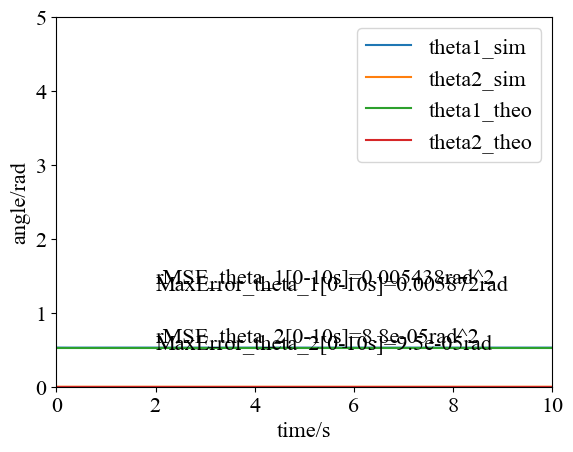

-1.053188197338355
-0.10386001743751985


In [12]:
def single_exp(StartPoint_index=0, EndPoint_index=0):
    i = StartPoint_index
    j = EndPoint_index
    group = i*100 + j
    t_matlab = ExpStructList_mat['ExpData'][0][group][0][:].flatten()
    # Xt_matlab = ExpStructList_mat['ExpData'][0][group][1][:]
    theta1_matlab = ExpStructList_mat['ExpData'][0][group][1][:, 0]
    theta2_matlab = ExpStructList_mat['ExpData'][0][group][1][:, 1]
    exp1data = np.array(data_matrix[i][j])
    t_bias = exp1data[0, 0]

    # check ang range
    if np.max(exp1data[:, 1]) > math.pi or np.min(exp1data[:, 1]) < -math.pi:
        print(f"theta1_mujoco Error in {i}, {j}")
    if np.max(exp1data[:, 2]) > math.pi or np.min(exp1data[:, 2]) < -math.pi:
        print(f"theta2_mujoco Error in {i}, {j}")

    if np.max(theta1_matlab) > math.pi or np.min(theta1_matlab) < -math.pi:
        print(f"theta1_matlab Error in {i}, {j}")
    if np.max(theta2_matlab) > math.pi or np.min(theta2_matlab) < -math.pi:
        print(f"theta2_matlab Error in {i}, {j}")


    error = step_response_compare(t_matlab.flatten(), theta1_matlab, theta2_matlab, exp1data[:, 0]-t_bias, (exp1data[:, 1]+math.pi/2), exp1data[:, 2], True)
    # if error[0] > 2:
    #     print(f"Error in {i}, {j}")
    # print(error)
    return error

single_exp()
print(np.min(exp1data[:, 1]))
print(np.min(exp1data[:, 2]))


In [13]:
def group_step_exps():
    error_list = []
    for i in tqdm(range(100)):
        for j in range(100):
            group = i*100 + j
            t_matlab = ExpStructList_mat['ExpData'][0][group][0][:].flatten()
            # Xt_matlab = ExpStructList_mat['ExpData'][0][group][1][:]
            theta1_matlab = ExpStructList_mat['ExpData'][0][group][1][:, 0]
            theta2_matlab = ExpStructList_mat['ExpData'][0][group][1][:, 1]
            exp1data = np.array(data_matrix[i][j])
            t_bias = exp1data[0, 0]
                # check ang range
            valid = True
            if np.max(exp1data[:, 1]+math.pi/2) > math.pi*2/3 or np.min(exp1data[:, 1]+math.pi/2) < math.pi/6:  # 0.02 original version
                # print(f"theta1_mujoco Error in {i}, {j}, {np.max(exp1data[:, 1]+math.pi/2)}, {np.min(exp1data[:, 1]+math.pi/2)}")
                valid = False
            if np.max(exp1data[:, 2]) > math.pi/2 or np.min(exp1data[:, 2]) < 0:
                # print(f"theta2_mujoco Error in {i}, {j}")
                valid = False
            if np.max(theta1_matlab) > math.pi*2/3 or np.min(theta1_matlab) < math.pi/6:  # 0.02 original version
                # print(f"theta1_matlab Error in {i}, {j}")
                valid = False
            if np.max(theta2_matlab) > math.pi/2 or np.min(theta2_matlab) < 0:
                # print(f"theta2_matlab Error in {i}, {j}")
                valid = False
            if valid:
                error = step_response_compare(t_matlab.flatten(), theta1_matlab, theta2_matlab, exp1data[:, 0]-t_bias, (exp1data[:, 1]+math.pi/2), exp1data[:, 2], False)
                # print(error)
                if error[0] > 2:
                    print(f"Error in {i}, {j}")
                    pass
                error_list.append(error)
    return np.array(error_list)

error_list = group_step_exps()


100%|██████████| 100/100 [00:13<00:00,  7.49it/s]


In [14]:
# 计算最大误差
print(error_list.shape) # 30% 的模型满足要求
max_rmse_theta1 = np.max(error_list[:, 0])
max_rmse_theta2 = np.max(error_list[:, 1])
max_mae_theta1 = np.max(error_list[:, 2])
max_mae_theta2 = np.max(error_list[:, 3])
max_maxerror_theta1 = np.max(error_list[:, 4])
max_maxerror_theta2 = np.max(error_list[:, 5])

print(f"max_rmse_theta1={max_rmse_theta1}")
print(f"max_rmse_theta2={max_rmse_theta2}")
print(f"max_mae_theta1={max_mae_theta1}")
print(f"max_mae_theta2={max_mae_theta2}")
print(f"max_maxerror_theta1={max_maxerror_theta1}")
print(f"max_maxerror_theta2={max_maxerror_theta2}")


(2407, 6)
max_rmse_theta1=0.009224429274616036
max_rmse_theta2=0.011476296604429372
max_mae_theta1=0.007876103987719712
max_mae_theta2=0.0068087055123486825
max_maxerror_theta1=0.0477560291343766
max_maxerror_theta2=0.12699038263777096
